# Experimento A/B en página de inicio

El objetivo de este proyecto es evaluar un **experimento A/B** realizado en una página de inicio (landing page) con versiones **A y B** para apoyar una **decisión de negocio basada en datos**.

---

El archivo `landing_experiment.csv` contiene información de usuarios expuestos a dos versiones de la página de inicio (landing page) dentro del experimento A/B. Incluye región, dispositivo, fuente de tráfico, tipo de usuario, conversión y gasto.

El análisis sigue una lógica clara y progresiva:

1. 🔍 Explorar y validar los datos.

2. 💰 Comparar el **gasto promedio** por usuario entre la página A y B.

3. 🎯 Comparar la **tasa de conversión** entre la página A y B.

4. 🌐 Revisar **la relación entre la fuente de tráfico y la conversión**.

5. 👤 Revisar **la relación entre el tipo de usuario y la conversión**.

6. 📈 **Visualizar los resultados**: Respalda tus conclusiones mediante gráficos claros.

Se aplican **pruebas estadísticas apropiadas** para comparar el desempeño de las páginas y sustentar las conclusiones con datos.

## 🧩 Paso 1: Cargar y validar los datos

### 1.1 Carga de datos y vista rápida

In [110]:

# importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración para mostrar las tablas y los gráficos
pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")


In [111]:

# cargar archivo
df = pd.read_csv('landing_experiment.csv')


**Vista previa e información general del conjunto de datos**

In [112]:
# mostrar las primeras 5 filas
display(df.head())

,user_id,date,landing,region,dispositivo,traffic_source,user_type,converted,gasto
0,26f3052e-8500-44ea-8fff-06de65258abb,2026-01-01,A,Norte,Mobile,Email,Recurrente,1,38.08
1,92378c09-4bbf-40c7-945e-82b84f392d22,2026-01-23,A,Occidente,Mobile,Organic,Nuevo,0,0.00
2,a4397360-40e5-45d6-a7ff-dcb4da2c9a1f,2026-01-01,B,Centro,Mobile,Organic,Nuevo,0,0.00
3,7ca3a26f-1e6c-44aa-9b09-b8cb01112956,2026-01-22,A,Centro,Mobile,Ads,Nuevo,0,0.00
4,8dc9593b-5b9c-479d-848b-a99493920419,2026-01-16,A,Sur,Mobile,Organic,Nuevo,0,0.00


In [113]:
# información general
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   user_id         40000 non-null  object 
 1   date            40000 non-null  object 
 2   landing         40000 non-null  object 
 3   region          40000 non-null  object 
 4   dispositivo     40000 non-null  object 
 5   traffic_source  40000 non-null  object 
 6   user_type       40000 non-null  object 
 7   converted       40000 non-null  int64  
 8   gasto           40000 non-null  float64
dtypes: float64(1), int64(1), object(7)
memory usage: 2.7+ MB


✍️ **Comentario**:

El conjunto de datos contiene 40.000 registros y 9 columnas. No se observan valores ausentes, ya que todas las columnas cuentan con 40.000 valores no nulos.

Los tipos de datos son adecuados para la mayoría de las variables: `converted` está almacenada como entero y `gasto` como decimal. Las variables categóricas están almacenadas como `object`. La columna `date` también aparece como `object`, por lo que, si se requiere realizar operaciones o análisis relacionados con fechas, será necesario convertirla posteriormente al formato de fecha correspondiente.

En general, los datos presentan una estructura adecuada para continuar con el análisis del experimento A/B.


**Descripción del conjunto de datos**

El dataset contiene las siguientes columnas:

- `user_id` — Identificador único del usuario
- `date` — Fecha en la que el usuario fue expuesto a la página
- `landing` — Versión de la página mostrada al usuario
- `region` — Región geográfica del usuario
- `dispositivo` — Tipo de dispositivo utilizado por el usuario
- `traffic_source` — Canal por el que llegó el usuario
- `user_type` — Tipo de usuario según historial previo
- `converted` — Indica si el usuario realizó una conversión
- `gasto` — Monto gastado por el usuario (0 si no convirtió)

### 1.2 Análisis exploratorio y revisión de calidad de datos

Se identifican las variables clave del experimento A/B y se valida que estén bien definidas, completas y que sean consistentes.


 **Variable `user_id`**  
 Verificar usuarios únicos

In [114]:
df["user_id"].nunique()
print("Usuarios únicos:", df["user_id"].nunique())

Usuarios únicos: 40000


 **Variable `date`**  
Explorar rango de fechas

In [115]:

# Resumen estadístico
df["date"].describe()


count          40000
unique            28
top       2026-01-24
freq            1512
Name: date, dtype: object

In [116]:

# Identificar rango temporal del experimento
print("Fecha mínima:", df["date"].min())
print("Fecha máxima:", df["date"].max())


Fecha mínima: 2026-01-01
Fecha máxima: 2026-01-28


**Variable `gasto` (numérica)**

In [117]:
# Resumen estadístico
df["gasto"].describe()

count    40000.000000
mean         9.325554
std         25.667986
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        303.680000
Name: gasto, dtype: float64

In [118]:
# Resumen estadístico de usuarios que se convirtieron
df[df["converted"] == 1]["gasto"].describe()

count    5706.000000
mean       65.373668
std        30.896545
min        12.120000
25%        42.950000
50%        59.860000
75%        80.370000
max       303.680000
Name: gasto, dtype: float64

 **Variables categóricas**  
 Verificar categorías esperadas del experimento ( A y B).

In [119]:

# Explorar variables categóricas y cómo se distribuyen
print("\nConteo de categorías:")
print(df[["landing", "region", "dispositivo", "traffic_source", "user_type"]].nunique())


Conteo de categorías:
landing           2
region            5
dispositivo       2
traffic_source    4
user_type         2
dtype: int64


In [120]:
print("\nCategorías de landing:")
print(df["landing"].unique())


Categorías de landing:
['A' 'B']


✍️ **Comentario**:

El conjunto de datos contiene 40.000 usuarios únicos, igual que el número de registros, por lo que no se observan usuarios duplicados.

El experimento se desarrolló entre el 1 y el 28 de enero de 2026. La variable `gasto` presenta valores entre 0 y 303,68. Al analizar únicamente los usuarios que realizaron una conversión, se identifican 5.706 usuarios y un gasto promedio de 65,37.

Las variables categóricas presentan las categorías esperadas: `landing` tiene 2 categorías, `region` 5, `dispositivo` 2, `traffic_source` 4 y `user_type` 2. Además, la variable `landing` contiene únicamente las versiones A y B del experimento.

No se identifican categorías inesperadas ni valores negativos en el gasto, por lo que los datos presentan condiciones adecuadas para continuar con el análisis.


## 💰 Paso 2: Comparar el gasto promedio por usuario (página A vs B)

Se evalúa si existen diferencias estadísticamente significativas en el gasto promedio de los **usuarios que se convirtieron en clientes** entre la página A y la página B, para identificar qué versión genera **mayor valor económico** para el negocio.


In [121]:
# Gasto por versión
gasto_A = df[(df["landing"] == "A") & (df["converted"] == 1)]["gasto"]
gasto_B = df[(df["landing"] == "B") & (df["converted"] == 1)]["gasto"]

# Verificar cantidad de datos que tiene cada grupo
len(gasto_A), len(gasto_B)

(2512, 3194)

In [122]:
print("Gasto promedio A:", gasto_A.mean())
print("Gasto promedio B:", gasto_B.mean())

Gasto promedio A: 61.0865724522293
Gasto promedio B: 68.74536005009392


### Prueba Bilateral

Porque la pregunta es si existe una diferencia, no estamos suponiendo de antemano que A tenga que ser mayor que B.

**Hipótesis:**
-
**Hipótesis nula** (H₀): El gasto promedio de los usuarios convertidos es igual entre las páginas A y B.

**Hipótesis alternativa** (H₁): El gasto promedio de los usuarios convertidos es diferente entre las páginas A y B.

In [123]:

from scipy import stats

# Aplicar prueba
resultado = stats.ttest_ind(gasto_A, gasto_B, equal_var=False)

# Visualizar resultados
print(f"Estadístico : {resultado.statistic}")
print(f"Valor p: {resultado.pvalue}")




Estadístico : -9.48101092267275
Valor p: 3.627602231521493e-21


In [124]:
if resultado.pvalue < 0.05:
    print("Rechazamos la hipótesis nula: existe una diferencia estadísticamente significativa en el gasto promedio entre las páginas A y B.")
else:
    print("No rechazamos la hipótesis nula: no existe evidencia suficiente de una diferencia en el gasto promedio entre las páginas A y B.")

Rechazamos la hipótesis nula: existe una diferencia estadísticamente significativa en el gasto promedio entre las páginas A y B.


In [125]:
print(f"Gasto promedio A: {gasto_A.mean():.2f}")
print(f"Gasto promedio B: {gasto_B.mean():.2f}")

Gasto promedio A: 61.09
Gasto promedio B: 68.75



### 📝 Conclusión e interpretación


**Decisión:**

Se rechaza la hipótesis nula, ya que el valor p es menor que 0,05. Existe evidencia estadísticamente significativa de una diferencia en el gasto promedio entre los usuarios convertidos de las páginas A y B.

**Interpretación de negocio:**

El gasto promedio de los usuarios convertidos fue de 61,09 en la página A y de 68,75 en la página B. La diferencia es de aproximadamente 7,66 unidades monetarias por usuario convertido. Por lo tanto, dentro de los usuarios que realizaron una conversión, la página B presenta un mayor gasto promedio y la diferencia observada es estadísticamente significativa.



---


## 📈 Paso 3: Comparar la tasa de conversión entre la página A y B

Se evalúa si existen diferencias estadísticamente significativas en la **tasa de conversión** entre la página A y B, con el fin de identificar qué versión genera **mayor número de usuarios convertidos**.

### Prueba Bilateral
Porque queremos determinar si existe una diferencia, sin establecer previamente cuál página debe tener la tasa mayor.

**Hipótesis:**

**Hipótesis nula** (H₀): La tasa de conversión es igual en las páginas A y B.

**Hipótesis alternativa** (H₁): La tasa de conversión es diferente entre las páginas A y B.


In [126]:


# Número de usuarios convertidos por página
convertidos = df.groupby("landing")["converted"].sum()

# Total de usuarios por página
total_usuarios = df.groupby("landing")["user_id"].count()

print("Usuarios convertidos por página:\n", convertidos)
print("\nTotal de usuarios por página:\n", total_usuarios)




Usuarios convertidos por página:
 landing
A    2512
B    3194
Name: converted, dtype: int64

Total de usuarios por página:
 landing
A    19982
B    20018
Name: user_id, dtype: int64


In [127]:
from statsmodels.stats.proportion import proportions_ztest

In [128]:

# Aplicar prueba

resultado_conversion = proportions_ztest(
    count=[convertidos["A"], convertidos["B"]],
    nobs=[total_usuarios["A"], total_usuarios["B"]]
)

# Visualizar resultados

print(f"Estadístico : {resultado_conversion[0]}")
print(f"Valor p: {resultado_conversion[1]}")


Estadístico : -9.677362674655983
Valor p: 3.7629765627523803e-22


In [ ]:
# Calcular las tasas de conversión y su diferencia
tasa_A = convertidos["A"] / total_usuarios["A"] * 100
tasa_B = convertidos["B"] / total_usuarios["B"] * 100

print(f"Tasa de conversión A: {tasa_A:.2f}%")
print(f"Tasa de conversión B: {tasa_B:.2f}%")
print(f"Diferencia: {tasa_B - tasa_A:.2f} puntos porcentuales")

Tasa de conversión A: 12.57%
Tasa de conversión B: 15.96%
Diferencia: 3.38 puntos porcentuales



### 📝 Conclusión e interpretación


📝 **Decisión**

Se rechaza la hipótesis nula, ya que el valor p (3,76 × 10⁻²²) es menor que 0,05. Existe evidencia estadísticamente significativa de una diferencia en la tasa de conversión entre las páginas A y B.

💼 **Interpretación de negocio**

La página A presentó una tasa de conversión aproximada de 12,57 %, mientras que la página B alcanzó 15,96 %. Esto representa una diferencia de aproximadamente 3,38 puntos porcentuales a favor de B. Además, la prueba estadística indica que esta diferencia es significativa, por lo que los resultados del experimento muestran una diferencia en la tasa de conversión entre ambas versiones.


## 🔗 Paso 4: Revisar la relación entre la fuente de tráfico y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre la **fuente de tráfico** (`traffic_source`) y la **conversión** (`converted`), para identificar qué canales generan más conversiones.

### Prueba chi-cuadrado de independencia.

**Hipótesis:**

**Hipótesis nula** (H₀): No existe asociación entre la fuente de tráfico y la conversión.

**Hipótesis alternativa** (H₁): Existe asociación entre la fuente de tráfico y la conversión.

**La pregunta estadística es:**

¿El hecho de que un usuario haya llegado por Organic, Ads, Email o Referral está relacionado con que convierta o no?

In [129]:
tabla_contingencia = pd.crosstab(df["traffic_source"], df["converted"])

In [130]:
# Aplicar prueba
resultado_chi2 = stats.chi2_contingency(tabla_contingencia)


In [131]:
# Visualizar resultados
print(f"Estadístico chi-cuadrado: {resultado_chi2[0]}")
print(f"Valor p: {resultado_chi2[1]}")

Estadístico chi-cuadrado: 8.662108841397938
Valor p: 0.0341375947833914


In [ ]:
# Calcular la proporción de conversión por fuente de tráfico
traffic_pct = pd.crosstab(
    df["traffic_source"],
    df["converted"],
    normalize="index"
) * 100

display(traffic_pct.round(2))

converted           0      1
traffic_source              
Ads             85.26  14.74
Email           85.01  14.99
Organic         86.21  13.79
Referral        86.12  13.88


### 📝 Conclusión e interpretación

📝 **Decisión**

Se rechaza la hipótesis nula, ya que el valor p de 0,0341 es menor que 0,05. Existe evidencia estadísticamente significativa de una asociación entre la fuente de tráfico y la conversión.

💼 **Interpretación de negocio**

La fuente Organic concentra la mayor cantidad de conversiones, con 2.480 usuarios convertidos, pero también es la fuente con mayor número de usuarios. Al comparar las tasas de conversión, Email presenta la tasa más alta con 14,99 %, seguida de Ads con 14,74 %, mientras que Referral alcanza 13,88 % y Organic 13,79 %. La prueba chi-cuadrado indica que las diferencias observadas entre las fuentes de tráfico y la conversión son estadísticamente significativas. Esto sugiere que el comportamiento de conversión varía según el canal de adquisición.



## 👤 Paso 5: Revisar la relación entre el tipo de usuario y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre el **tipo de usuario** (`user_type`) y la **conversión** (`converted`), entendiendo que un usuario recurrente puede haber visitado antes sin necesariamente convertirse en cliente en esta ocasión.

El objetivo es analizar si existen diferencias en la conversión según el tipo de usuario dentro del contexto analizado.

### Prueba chi-cuadrado de independencia.

**Hipótesis:**

**Hipótesis nula** (H₀): No existe asociación entre el tipo de usuario y la conversión.

**Hipótesis alternativa** (H₁): Existe asociación entre el tipo de usuario y la conversión.

In [132]:
tabla_usuario = pd.crosstab(df["user_type"], df["converted"])

In [133]:
tabla_usuario_pct = pd.crosstab(
    df["user_type"],
    df["converted"],
    normalize="index"
) * 100

In [134]:
# Aplicar prueba
resultado_usuario = stats.chi2_contingency(tabla_usuario)
print(f"Estadístico chi-cuadrado: {resultado_usuario[0]}")
print(f"Valor p: {resultado_usuario[1]}")

Estadístico chi-cuadrado: 0.5134849494478645
Valor p: 0.4736341272301974


### 📝 Conclusión e interpretación

📝 **Decisión**

No rechazamos la hipótesis nula, ya que el valor p (0,4736) es mayor que 0,05. No existe evidencia estadística suficiente para afirmar que haya una asociación entre el tipo de usuario y la conversión.

💼 **Interpretación de negocio**

En este experimento, no se encontró evidencia estadísticamente significativa de una relación entre ser un usuario nuevo o recurrente y realizar una conversión. Con los datos analizados, no se encontró evidencia estadísticamente significativa de una asociación entre el tipo de usuario y la conversión.

## 📊 Paso 6: Visualizar los resultados de variables categóricas

Se explora visualmente la relación entre variables categóricas (`traffic_source` y `user_type`) y la conversión, mostrando para cada categoría:
- la cantidad absoluta de usuarios que convirtieron y no convirtieron,
- la proporción de usuarios que convirtieron y no convirtieron.

Esto permite analizar tanto el impacto en volumen como la efectividad relativa de cada categoría y reforzar los resultados obtenidos en las pruebas estadísticas.

### Relación entre la fuente de tráfico y la conversión

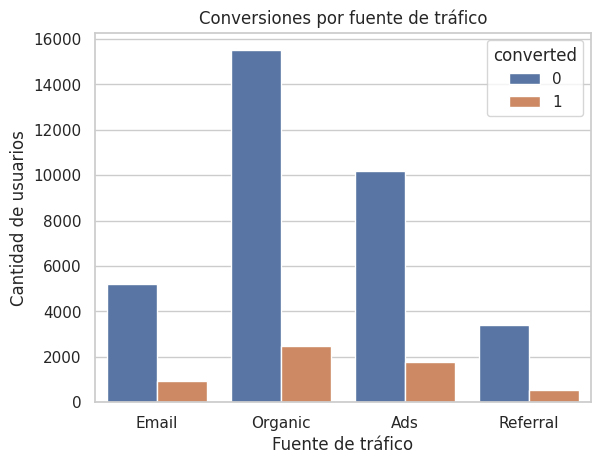

In [135]:
# Cantidad de usuarios que convirtieron y no convirtieron según la fuente de tráfico
sns.countplot(data=df, x="traffic_source", hue="converted")
plt.title("Conversiones por fuente de tráfico")
plt.xlabel("Fuente de tráfico")
plt.ylabel("Cantidad de usuarios")
plt.show()

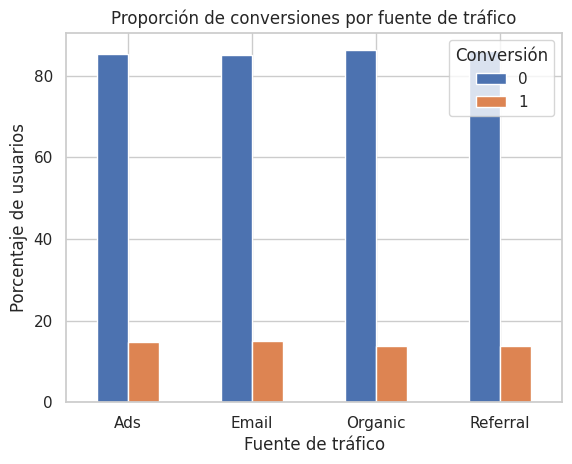

In [136]:
# Proporción de usuarios que convirtieron y no convirtieron según la fuente de tráfico
traffic_pct = pd.crosstab(df["traffic_source"], df["converted"], normalize="index") * 100

traffic_pct.plot(kind="bar")
plt.title("Proporción de conversiones por fuente de tráfico")
plt.xlabel("Fuente de tráfico")
plt.ylabel("Porcentaje de usuarios")
plt.legend(title="Conversión")
plt.xticks(rotation=0)
plt.show()


✍️ **Comentario**:

En el gráfico de cantidades, la fuente Organic concentra el mayor número de usuarios convertidos y no convertidos, seguida de Ads, Email y Referral. Esto se relaciona con el volumen de usuarios de cada fuente, por lo que una mayor cantidad de conversiones no necesariamente significa una mayor efectividad.

Al observar las proporciones, las diferencias entre las fuentes son más pequeñas. Email presenta la mayor proporción de conversiones, seguida de Ads, mientras que Referral y Organic presentan proporciones ligeramente menores. Estos resultados permiten complementar la prueba chi-cuadrado, que mostró una asociación estadísticamente significativa entre la fuente de tráfico y la conversión.


### Relación entre el tipo de usuario y la conversión

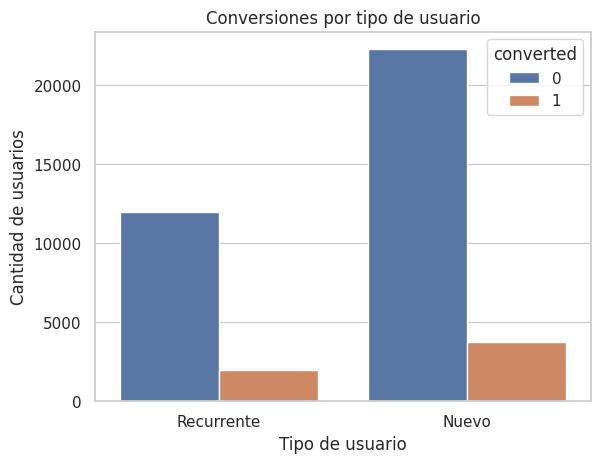

In [137]:
# Cantidad de usuarios que convirtieron y no convirtieron según el tipo de usuario
sns.countplot(data=df, x="user_type", hue="converted")
plt.title("Conversiones por tipo de usuario")
plt.xlabel("Tipo de usuario")
plt.ylabel("Cantidad de usuarios")
plt.show()

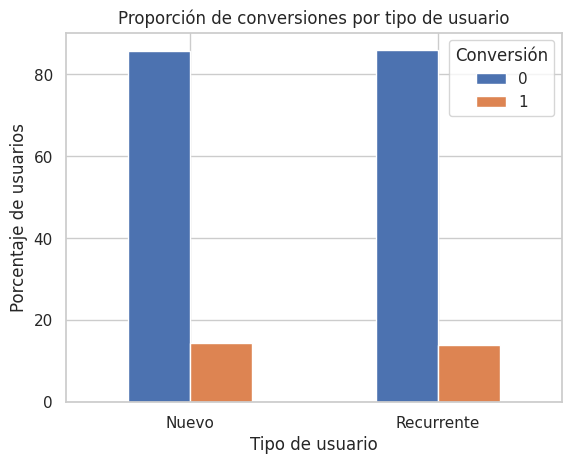

In [138]:
# Proporción de usuarios que convirtieron y no convirtieron según el tipo de usuario
user_type_pct = pd.crosstab(
    df["user_type"],
    df["converted"],
    normalize="index"
) * 100

user_type_pct.plot(kind="bar")
plt.title("Proporción de conversiones por tipo de usuario")
plt.xlabel("Tipo de usuario")
plt.ylabel("Porcentaje de usuarios")
plt.legend(title="Conversión")
plt.xticks(rotation=0)
plt.show()


✍️ **Comentario**: 

En el gráfico de cantidades se observa que los usuarios nuevos tienen un mayor número de conversiones que los usuarios recurrentes. Sin embargo, esto está relacionado con que también hay una mayor cantidad de usuarios nuevos en el conjunto de datos.

Al analizar las proporciones, las tasas de conversión de ambos tipos de usuarios son muy similares. Esto coincide con el resultado de la prueba chi-cuadrado, cuyo valor p fue de 0,4736, por lo que no se encontró evidencia estadística suficiente para afirmar que exista una asociación entre el tipo de usuario y la conversión.




### 🌟 Insight Ejecutivo basado en el Experimento A/B

#### 🔍 **Comparación de página (A vs B)**  

**Gasto promedio por usuario que convirtió:**
- Página A: **61,09**
- Página B: **68,75**
- **Interpretación:** Entre los usuarios que realizaron una conversión, el gasto promedio fue mayor en la página B, con una diferencia de **7,66 unidades monetarias**. La prueba t mostró que esta diferencia es estadísticamente significativa (p < 0,05).

<br>

**Tasa de conversión:** 
- Página A: **12,57 %**
- Página B: **15,96 %**
- **Interpretación:** La página B presentó una tasa de conversión **3,38 puntos porcentuales mayor** que la página A. La prueba de proporciones mostró que esta diferencia es estadísticamente significativa (p < 0,05).

---

#### 📊 **Segmentación por fuente de tráfico**
- **Observación:** Organic concentra el mayor número absoluto de conversiones debido a su mayor volumen de usuarios. Al comparar las proporciones, Email presenta la mayor tasa de conversión, seguida de Ads.
- **Interpretación:** La prueba chi-cuadrado mostró una asociación estadísticamente significativa entre la fuente de tráfico y la conversión (p = 0,0341). Por lo tanto, el comportamiento de conversión presenta diferencias según la fuente de tráfico.

---

#### 📊 **Segmentación por tipo de usuario**
- **Observación:** Los usuarios nuevos presentan más conversiones en términos absolutos debido a que representan un grupo más grande. Sin embargo, las proporciones de conversión entre usuarios nuevos y recurrentes son muy similares.
- **Interpretación:** La prueba chi-cuadrado no encontró evidencia estadística suficiente de una asociación entre el tipo de usuario y la conversión (p = 0,4736).

---

Las visualizaciones usadas respaldan los resultados estadísticos de pasos anteriores.

---

#### 💡 **Recomendaciones de negocio:** 
- **Considerar la página B como referencia para futuras iteraciones del experimento**, ya que presentó una mayor tasa de conversión y un mayor gasto promedio entre los usuarios que convirtieron.
- **Profundizar en el desempeño y la rentabilidad de las fuentes de tráfico**, especialmente Email y Organic, incorporando métricas de costos e ingresos antes de tomar decisiones de inversión.